In [ ]:
import time
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt
from torchvision import datasets, transforms, utils
from torch.utils.data import DataLoader
%cd "C:/Users/mateo/Desktop/polymath-jr-drifting"
# This notebook uses DriftXpress; exact drift uses its separate loss/cache API in src.drift.
from src.driftXpress import *
from src.eval import *
from src.training import (
    compose_objective,
    format_epoch_losses,
    gradient_report,
    per_loss_gradient_norms,
    set_requires_grad,
)
torch.manual_seed(7)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using:", device)


In [2]:
transform = transforms.ToTensor()

SELECTED_DIGITS = (0, 8, 2, 4, 7, 9)
DIGIT_TO_CLASS = {digit: index for index, digit in enumerate(SELECTED_DIGITS)}
CLASS_TO_DIGIT = np.asarray(SELECTED_DIGITS)

train_data = datasets.MNIST("data", train=True, download=True, transform=transform)
test_data = datasets.MNIST("data", train=False, download=True, transform=transform)

def keep_selected_digits(dataset):
    selected = torch.tensor(SELECTED_DIGITS, dtype=dataset.targets.dtype)
    mask = torch.isin(dataset.targets, selected)
    dataset.data = dataset.data[mask]
    raw_targets = dataset.targets[mask]
    dataset.targets = torch.tensor(
        [DIGIT_TO_CLASS[int(digit)] for digit in raw_targets],
        dtype=torch.long,
    )
    return dataset

train_data = keep_selected_digits(train_data)
test_data = keep_selected_digits(test_data)

BATCH_SIZE = 500

train_loader = DataLoader(
    train_data,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)
test_loader = DataLoader(
    test_data,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)

print("Selected digits:", SELECTED_DIGITS)
print("Train samples:", len(train_data))
print("Test samples:", len(test_data))


Selected digits: (0, 8, 2, 4, 7, 9)
Train samples: 35788
Test samples: 6005


In [3]:
class f(nn.Module):
    def __init__(self, input_dim=784, latent_dim=16, num_classes=6, label_dim=16):
        super().__init__()
        self.latent_dim = latent_dim
        self.num_classes = num_classes
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 192), nn.LeakyReLU(0.2),
            nn.Linear(192, 96), nn.LeakyReLU(0.2),
        )
        self.fc_mu = nn.Linear(96, latent_dim)
        self.fc_var = nn.Linear(96, latent_dim)
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 96), nn.LeakyReLU(0.2),
            nn.Linear(96, 192), nn.LeakyReLU(0.2),
            nn.Linear(192, input_dim), nn.Sigmoid(),
        )
        self.embedding = nn.Embedding(num_classes, label_dim)
        self.generator = nn.Sequential(
            nn.Linear(latent_dim + label_dim, 48), nn.SiLU(),
            nn.Linear(48, 48), nn.SiLU(),
            nn.Linear(48, 48), nn.SiLU(),
            nn.Linear(48, latent_dim),
        )

    def reparameterize(self, mu, logvar):
        return mu + torch.randn_like(logvar) * torch.exp(0.5 * logvar)

    def get_latent(self, x):
        h = self.encoder(x)
        mu, logvar = self.fc_mu(h), self.fc_var(h)
        return mu, logvar, self.reparameterize(mu, logvar)

    def encode_mu(self, x):
        return self.fc_mu(self.encoder(x))

    def decode(self, z):
        return self.decoder(z)

    def generate(self, noise, labels):
        h = torch.cat([noise, self.embedding(labels.long())], dim=1)
        z = self.generator(h)
        return z, self.decode(z)


In [30]:
model = f()
total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total_params}")
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters: {trainable_params}")

Total parameters: 351088
Trainable parameters: 351088


In [4]:
# The drift field is evaluated on detached inputs, but the loss remains
# differentiable with respect to \`generated\`.
# Therefore this loss sends gradients to the module that produced \`generated\`.
def drift_loss(generated, landmarks, K_uu_inv_sqrt, Ap, bp, T):
    with torch.no_grad():
        V = compute_V(generated.detach(), landmarks, K_uu_inv_sqrt, Ap, bp, T)
        frozen_targets = (generated.detach() + V).detach()
    return F.mse_loss(generated, frozen_targets), V


In [ ]:
def pretrain_vae(model, data_loader, epochs, lambda_kl, lambda_l1, lr=1e-3):
    """Pretrain only the VAE before the drift reference cache is built."""
    vae_parameters = (
        list(model.encoder.parameters())
        + list(model.fc_mu.parameters())
        + list(model.fc_var.parameters())
        + list(model.decoder.parameters())
    )
    optimizer = optim.AdamW(vae_parameters, lr=lr)
    history = []

    print(f"Pretraining VAE for {epochs} epochs...")
    for epoch in range(1, epochs + 1):
        model.train()
        total = 0.0
        for images, _ in data_loader:
            x = images.to(device, non_blocking=True).flatten(start_dim=1)
            mu, logvar, z = model.get_latent(x)
            reconstruction = model.decode(z)
            mse = recon_loss(reconstruction, x)
            l1 = F.l1_loss(reconstruction, x)
            kl = kl_loss(mu, logvar)
            loss = mse + lambda_l1 * l1 + lambda_kl * kl

            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(vae_parameters, 5.0)
            optimizer.step()
            total += loss.item()

        mean_loss = total / len(data_loader)
        history.append(mean_loss)
        if epoch == 1 or epoch % 5 == 0 or epoch == epochs:
            print(f"VAE pretrain epoch {epoch}/{epochs}: loss={mean_loss:.6f}")
    return history


def build_conditional_drift_cache(model, data_loader, num_classes, num_landmarks, T):
    # Build fixed class-conditional attraction summaries once, using deterministic
    # encoder means rather than sampled VAE latents.
    model.eval()
    references = {digit: [] for digit in range(num_classes)}
    with torch.no_grad():
        for images, labels in data_loader:
            x = images.to(device, non_blocking=True).flatten(start_dim=1)
            z_mu = model.encode_mu(x)
            labels = labels.to(device, non_blocking=True)
            for digit in range(num_classes):
                mask = labels == digit
                if mask.any():
                    references[digit].append(z_mu[mask].detach())

    cache = {}
    bank = []
    for digit in range(num_classes):
        if not references[digit]:
            raise ValueError(f"No reference samples found for digit {digit}.")
        support = torch.cat(references[digit], dim=0)
        bank.append(support)
        landmarks = select_landmarks(support, num_landmarks)
        W = build_nystrom_cache(landmarks, T)
        A, b = pre_compute_summaries(support, landmarks, W, T)
        cache[digit] = (landmarks, W, A, b)
    return cache, torch.cat(bank, dim=0)


def conditional_drift_loss(generated, labels, cache, T):
    total = generated.new_zeros(())
    field = torch.zeros_like(generated)
    batch_size = generated.shape[0]
    for digit_tensor in torch.unique(labels):
        digit = int(digit_tensor.item())
        mask = labels == digit
        landmarks, W, A, b = cache[digit]
        digit_loss, digit_field = drift_loss(
            generated[mask], landmarks, W, A, b, T
        )
        total = total + (mask.float().sum() / batch_size) * digit_loss
        field[mask] = digit_field
    return total, field


def training_loop(num_epochs, T, num_landmarks,
                  lambda_kl, lambda_drift, lambda_var, lambda_cov,
                  lambda_representation=1.0, loss_scale=1.0,
                  lambda_l1=0.0, vae_pretrain_epochs=25,
                  batch_size=1000, lr=1e-3):
    global DRIFT_CACHE
    model = f(784, LATENT_DIM, NUM_CLASSES).to(device)
    pretrain_vae(
        model, train_loader, vae_pretrain_epochs,
        lambda_kl=lambda_kl, lambda_l1=lambda_l1, lr=lr,
    )

    print("Building fixed conditional attraction caches from encoder means...")
    cache_start = time.perf_counter()
    cache, _ = build_conditional_drift_cache(
        model, train_loader, NUM_CLASSES, num_landmarks, T
    )
    DRIFT_CACHE = cache
    print(
        "Fixed attraction caches built in "
        f"{(time.perf_counter() - cache_start) / 60:.2f} minutes"
    )

    optimizer = optim.AdamW(model.parameters(), lr=lr)
    train_losses, recon_losses, kl_losses = [], [], []
    drift_losses, var_losses, covar_losses = [], [], []
    average_V, evolution = [], []

    print("Algorithm 5 fully joint conditional training started")
    snapshots = set(range(0, num_epochs + 1, max(1, num_epochs // 5)))
    snapshots.add(num_epochs)
    train_start = time.perf_counter()

    for epoch in range(num_epochs + 1):
        model.train()
        items = {k: 0.0 for k in
                 ("total", "recon", "kl", "drift", "drift_reencoded",
                  "drift_raw", "var", "covar", "V")}
        last_pos, last_neg = None, None

        for images, labels in train_loader:
            x = images.to(device, non_blocking=True).flatten(start_dim=1)
            labels = labels.to(device, non_blocking=True)
            noise = torch.randn(x.shape[0], model.latent_dim, device=device)

            mu, logvar, z_pos = model.get_latent(x)
            x_recon = model.decode(z_pos)
            z_raw, x_neg = model.generate(noise, labels)
            z_neg = model.encode_mu(x_neg)

            # Path 1: re-encoded drift. This sends gradients through the
            # decoder and encoder, as well as through the generator.
            L_drift_reencoded, V_reencoded = conditional_drift_loss(
                z_neg, labels, cache, T
            )
            # Path 2: raw generator-latent drift. This gives a direct signal
            # to the generator before the decoder/re-encoder path.
            L_drift_raw, V_raw = conditional_drift_loss(
                z_raw, labels, cache, T
            )
            # Average the two paths so the drift scale stays comparable to
            # Algorithm 3 while both paths contribute gradients.
            L_drift = 0.5 * (L_drift_reencoded + L_drift_raw)
            V = 0.5 * (V_reencoded + V_raw)

            L_var = variance_loss(mu) + variance_loss(z_neg)
            L_cov = covariance_loss(mu) + covariance_loss(z_neg)
            mse = recon_loss(x_recon, x)
            l1 = F.l1_loss(x_recon, x)
            L_recon = mse + lambda_l1 * l1
            L_kl = kl_loss(mu, logvar)
            loss, _ = compose_objective(
                {
                    "recon": L_recon,
                    "kl": L_kl,
                    "drift": L_drift,
                    "var": L_var,
                    "covar": L_cov,
                },
                {
                    "kl": lambda_kl,
                    "drift": lambda_drift,
                    "var": lambda_var,
                    "covar": lambda_cov,
                },
                lambda_representation=lambda_representation,
                loss_scale=loss_scale,
            )
            if not torch.isfinite(loss):
                raise FloatingPointError(
                    f"Non-finite loss at epoch {epoch}: {loss.item()}"
                )

            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            optimizer.step()

            items["total"] += loss.item()
            items["recon"] += L_recon.item()
            items["kl"] += L_kl.item()
            items["drift"] += L_drift.item()
            items["drift_reencoded"] += L_drift_reencoded.item()
            items["drift_raw"] += L_drift_raw.item()
            items["var"] += L_var.item()
            items["covar"] += L_cov.item()
            items["V"] += V.norm(dim=1).mean().item()
            last_pos, last_neg = z_pos.detach(), z_neg.detach()

        n = len(train_loader)
        for key in items:
            items[key] /= n
        train_losses.append(items["total"])
        recon_losses.append(items["recon"])
        kl_losses.append(items["kl"])
        drift_losses.append(items["drift"])
        var_losses.append(items["var"])
        covar_losses.append(items["covar"])
        average_V.append(items["V"])
        if epoch in snapshots:
            evolution.append({"epoch": epoch, "pos": last_pos.cpu().numpy(),
                              "neg": last_neg.cpu().numpy()})

        if epoch < 20 or epoch % 10 == 0 or epoch == num_epochs:
            print(f"-------- Epoch {epoch} --------")
            print(f"total={items['total']:.6f}")
            print(f"recon={items['recon']:.6f}    scaled={loss_scale * lambda_representation * items['recon']:.6f}")
            print(f"kl={items['kl']:.6f}    scaled={loss_scale * lambda_representation * lambda_kl * items['kl']:.6f}")
            print(f"drift={items['drift']:.6f}    scaled={loss_scale * lambda_drift * items['drift']:.6f}")
            print(f"  re-encoded={items['drift_reencoded']:.6f}")
            print(f"  raw latent={items['drift_raw']:.6f}")
            print(f"var={items['var']:.6f}    scaled={loss_scale * lambda_representation * lambda_var * items['var']:.6f}")
            print("distances", torch.cdist(z_pos[:50], z_pos[:50]).mean().item())
            print(f"covar={items['covar']:.6f}    scaled={loss_scale * lambda_representation * lambda_cov * items['covar']:.6f}")
            print(f"average |V|={items['V']:.6f}")
            print(f"latent std positive={last_pos.std(dim=0).mean().item():.6f}")
            print(f"latent std negative={last_neg.std(dim=0).mean().item():.6f}")

    print(f"Finished. Joint training took {(time.perf_counter() - train_start) / 60:.2f} minutes")
    return (model, train_losses, recon_losses, kl_losses,
            drift_losses, var_losses, covar_losses, average_V, evolution)


In [ ]:
NUM_CLASSES = 6
LATENT_DIM = 32
VAE_PRETRAIN_EPOCHS = 25
NUM_EPOCHS = 100
NUM_LANDMARKS = 200
LAMBDA_DRIFT = 30.0
TEMPERATURE = 2
LAMBDA_L1 = 0.0
LAMBDA_KL = 1e-5
LAMBDA_VAR = 0.1
LAMBDA_COV = 0.3
LAMBDA_REPRESENTATION = 1.0
LOSS_SCALE = 1.0  # Global multiplier; leave at 1 unless intentionally testing it.

f_trained, losses, recon_losses, kl_losses, drift_losses, var_losses, covar_losses, average_V, evolution = training_loop(
    NUM_EPOCHS, TEMPERATURE, NUM_LANDMARKS, LAMBDA_KL, LAMBDA_DRIFT,
    LAMBDA_VAR, LAMBDA_COV, lambda_l1=LAMBDA_L1,
    vae_pretrain_epochs=VAE_PRETRAIN_EPOCHS,
    lambda_representation=LAMBDA_REPRESENTATION,
    loss_scale=LOSS_SCALE,
    batch_size=BATCH_SIZE, lr=1e-3,
)


In [20]:
f_trained.train()
images, labels = next(iter(train_loader))
x = images.to(device).flatten(start_dim=1)
labels = labels.to(device)
noise = torch.randn(x.shape[0], f_trained.latent_dim, device=device)
mu, logvar, z_pos = f_trained.get_latent(x)
z_raw, x_neg = f_trained.generate(noise, labels)
z_neg = f_trained.encode_mu(x_neg)
L_reencoded, _ = conditional_drift_loss(z_neg, labels, DRIFT_CACHE, TEMPERATURE)
L_raw, _ = conditional_drift_loss(z_raw, labels, DRIFT_CACHE, TEMPERATURE)
print("Re-encoded drift gradients:", gradient_report(L_reencoded, f_trained))
print("Raw latent drift gradients:", gradient_report(L_raw, f_trained))


Re-encoded drift gradients: {'encoder': {'total_norm': 0.2612630110234022, 'nonzero_parameters': 6, 'parameter_count': 8}, 'decoder': {'total_norm': 0.08375437097856775, 'nonzero_parameters': 6, 'parameter_count': 6}, 'generator': {'total_norm': 0.2525255889631808, 'nonzero_parameters': 8, 'parameter_count': 8}, 'other': {'total_norm': 0.0089847007766366, 'nonzero_parameters': 1, 'parameter_count': 1}}
Raw latent drift gradients: {'encoder': {'total_norm': 0.0, 'nonzero_parameters': 0, 'parameter_count': 8}, 'decoder': {'total_norm': 0.0, 'nonzero_parameters': 0, 'parameter_count': 6}, 'generator': {'total_norm': 0.23226153571158648, 'nonzero_parameters': 8, 'parameter_count': 8}, 'other': {'total_norm': 0.007562374696135521, 'nonzero_parameters': 1, 'parameter_count': 1}}


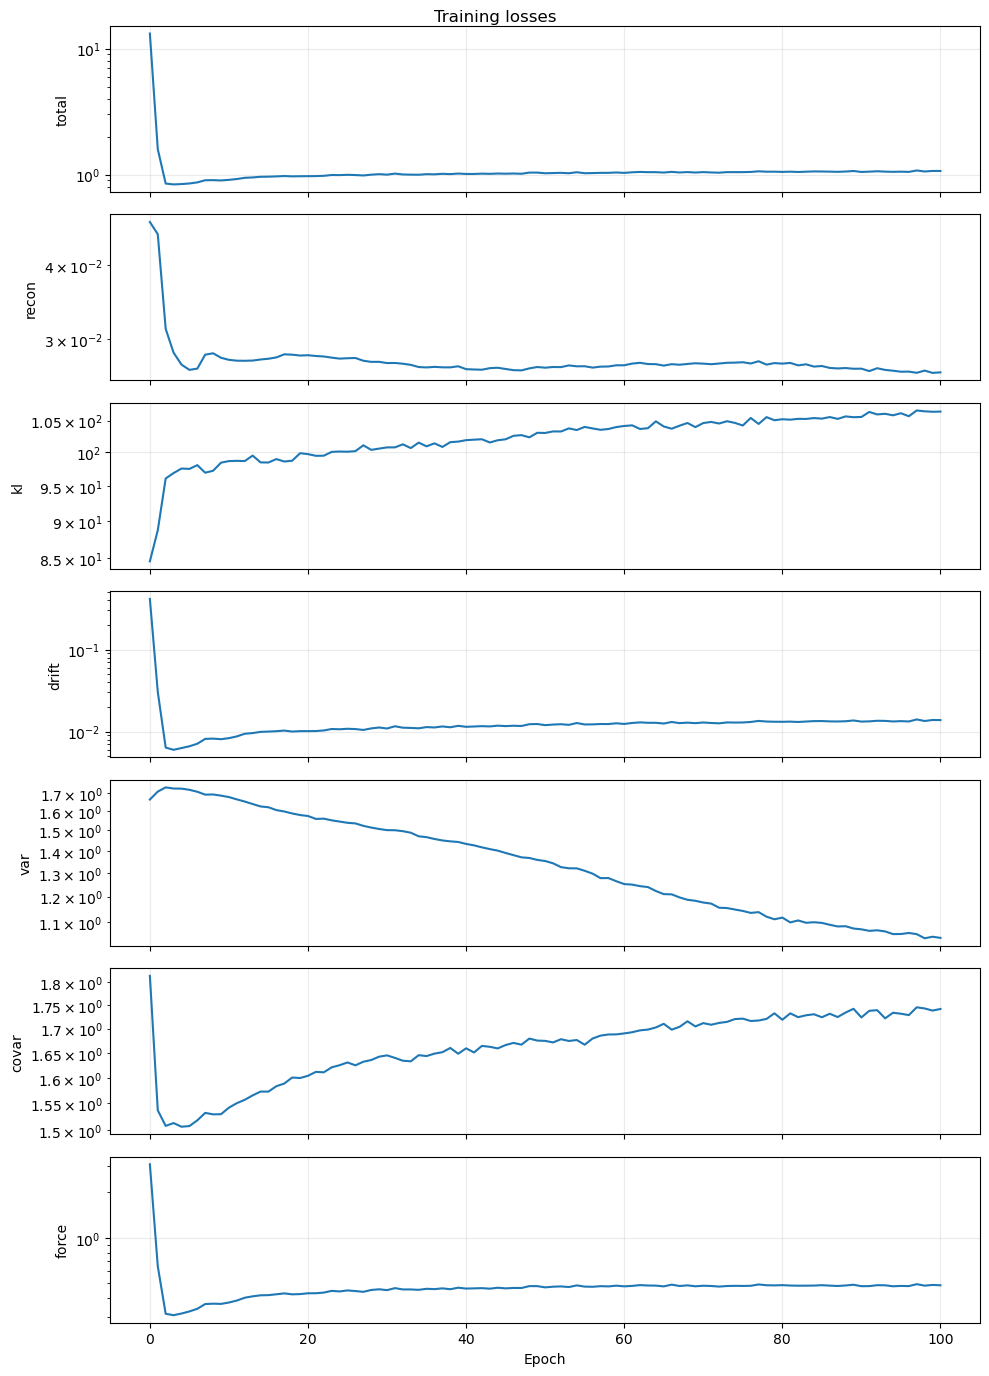

In [21]:
history = {
    "total": losses, "recon": recon_losses, "kl": kl_losses,
    "drift": drift_losses, "var": var_losses,
    "covar": covar_losses, "force": average_V,
}
fig, axes = plot_loss_history(history)
plt.show()


In [ ]:
# One reusable post-training call: it collects real encoder means and
# conditional generated latents/images, then computes latent SWD/FID and class metrics.
post_eval = evaluate_latent_model(
    f_trained,
    test_loader,
    device=device,
    n_samples=2048,
    n_classes=NUM_CLASSES,
    class_to_label=CLASS_TO_DIGIT,
    include_mmd=False,
    include_fid=True,
)

samples = post_eval["samples"]
real_latents = samples["real_latents"]
generated_latents = samples["generated_latents"]
real_pixels = samples["real_images"]
generated_pixels = samples["generated_images"]
real_class_labels = samples["real_class_ids"]
generated_class_labels = samples["generated_class_ids"]
real_labels = samples["real_labels"]
generated_labels = samples["generated_labels"]
metrics = post_eval["metrics"]
latent_stats = post_eval["statistics"]

print("Latent-space metrics:")
for name, value in metrics.items():
    print(f"{name}: {value:.6f}")


In [ ]:
# This is the same compact metric interface in pixel space.
# Its FID is a pixel-space Fréchet distance; use evaluate_mnist_generation with a
# frozen evaluator when you specifically want learned MNIST-feature FID.
pixel_metrics = evaluate_generation(
    real_pixels,
    generated_pixels,
    generated_labels=generated_class_labels,
    n_classes=NUM_CLASSES,
    include_mmd=False,
)
print("Pixel-space metrics:")
for name, value in pixel_metrics.items():
    print(f"{name}: {value:.6f}")


In [ ]:
print("Latent statistics:")
for name, value in latent_stats.items():
    print(f"{name}: {value:.6f}")


In [ ]:
fig, axes = plot_conditional_mnist_results(
    f_trained,
    test_loader,
    device=device,
    samples=10,
    use_mean_for_reconstruction=True,
)
plt.show()


In [ ]:
projection_figures = plot_real_generated_projections(
    real_latents,
    generated_latents,
    real_labels=real_labels,
    generated_labels=generated_labels,
    methods=("pca", "umap"),
)
plt.show()
